# Culvert GIS Reconstruction and Hydraulic-Validity Checks (1D)

In [1]:
#!pip install --upgrade ras-commander

## Development Mode

Set `USE_LOCAL_SOURCE = True` when running from a local ras-commander checkout.
The committed default uses the installed package; repository test execution can
still use local source through `PYTHONPATH`.

In [2]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = False

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path

    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: loading from {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE: loading installed ras-commander")

import logging
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Rectangle

from ras_commander import HdfResultsPlan, RasCmdr, RasPrj, init_ras_project
from ras_commander.geom import GeomCrossSection, GeomCulvert, GeomCulvertGIS
from ras_commander.sources.federal.usgs_sciencebase import UsgsScienceBase

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

PIP PACKAGE MODE: loading installed ras-commander


c:\Users\bill\anaconda3\envs\rascommander\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: G:\GH\ras-commander-wt-culverts\ras_commander\__init__.py


# Culvert GIS Reconstruction and Hydraulic-Validity Checks

HEC-RAS does not store a GIS polyline for a 1D culvert barrel -- the barrel's
planimetric line is *derived* from data that does live in the plain-text
geometry: the bounding cross-section GIS cut lines, the culvert's upstream and
downstream cross-section stations, the structure's `US Distance`, and the reach
lengths of the upstream bounding cross section.

This notebook uses `GeomCulvertGIS` to:

- **Reconstruct** each culvert barrel's planimetric line for plan-view display.
- **Validate** a culvert's placement against hydraulic-validity rules:
  - culvert inverts not buried below the bounding cross-section thalweg,
  - entrance/exit loss coefficients in line with HDS-5 / HEC-RAS guidance,
  - a reconstructed-vs-entered barrel-length consistency indicator.
- **Compare culvert designs** hydraulically -- here a real-world pipe -> box
  retrofit at a stream crossing, computed with HEC-RAS.

The data are the USGS Squannacook stream-crossing models (Massachusetts):
georeferenced 1D steady HEC-RAS models built to compare culvert shapes (pipe,
arch, box) at 16 crossings.

## Download the model and pick a crossing

The model comes from USGS ScienceBase. Each crossing carries design alternatives
in separate geometries (pipe / arch / box). We focus on the **Meadow Road**
crossing (river `40273_Unnamed Tr`), comparing the existing **pipe** culvert
(geometry `g06`, plan `02`) against a **box** retrofit (geometry `g16`, plan
`06`).

In [3]:
RAS_EXE = Path(os.environ.get(
    "HECRAS_EXE", r"C:/Program Files (x86)/HEC/HEC-RAS/7.0/Ras.exe"))

cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "ras_commander").exists() else cwd.parent
WORK_ROOT = Path(os.environ.get(
    "RAS_COMMANDER_WORKDIR", REPO_ROOT / "working" / "culvert_gis"))
WORK_ROOT.mkdir(parents=True, exist_ok=True)

# Download the Squannacook stream-crossing models (~9 MB) from USGS ScienceBase.
model_dir = UsgsScienceBase.download_model("squannacook", WORK_ROOT, required_only=True)
project_path = UsgsScienceBase.get_project_path("squannacook", WORK_ROOT)
print(f"Project: {project_path}")

if not RAS_EXE.exists():
    raise FileNotFoundError(f"HEC-RAS executable not found: {RAS_EXE}")

ras = RasPrj()
init_ras_project(project_path, str(RAS_EXE), ras_object=ras, load_results_summary=False)

# Crossing + design alternatives
RIVER = "40273_Unnamed Tr"
GEOM_PIPE = project_path.parent / "Squannacook.g06"   # existing pipe
GEOM_BOX = project_path.parent / "Squannacook.g16"    # box retrofit
PLAN_PIPE = "02"
PLAN_BOX = "06"

display(ras.plan_df[ras.plan_df["plan_number"].astype(str).str.zfill(2).isin([PLAN_PIPE, PLAN_BOX])][
    ["plan_number", "Plan Title", "Geom File", "Flow File", "flow_type"]])

Project: G:\GH\ras-commander-wt-culverts\working\culvert_gis\squannacook\Squannacook.prj


,plan_number,Plan Title,Geom File,Flow File,flow_type
1,02,SCSPipe_surveyXS,06,01,Steady
5,06,SCSBoxHm_survey,16,01,Steady


## Inventory the culverts in the existing (pipe) geometry

In [4]:
all_culverts = GeomCulvert.get_all(GEOM_PIPE)
print(f"{len(all_culverts)} culvert structures in {GEOM_PIPE.name}")
display(all_culverts[["River", "Reach", "RS", "CulvertName", "ShapeName",
                      "Span", "Rise", "Length"]].head(20))

# Our crossing of interest
struct = all_culverts[all_culverts["River"].astype(str).str.contains("40273")].iloc[0]
REACH = struct["Reach"]
RS = str(struct["RS"])
print(f"\nCrossing: {RIVER} / {REACH} / RS {RS}")

16 culvert structures in Squannacook.g06


,River,Reach,RS,CulvertName,ShapeName,Span,Rise,Length
0,40273_Unnamed Tr,Meadow Road,73,Culvert #1,Circular,6.00,6.00,40.0
1,40382_Unnamed Tr,Dudley Road,96,Culvert #1,Circular,6.75,6.75,62.0
2,40480_Unnamed Tr,Barker Hill Road,55,Culvert #1,Circular,5.50,5.50,35.5
3,40791_Trout Broo,Shirley Road,72,Culvert #1,Circular,7.25,7.25,62.0
4,41427_Unnamed Tr,Worcester Road,72,Culvert #1,Circular,5.00,5.00,26.5
5,55501_Witch Broo,Ash Street,111,Culvert #1,Circular,13.50,13.50,66.0
6,55502_Squannacoo,River Road,77,Culvert #1,Circular,11.50,11.50,47.0
7,55504_Unnamed Tr,Turnpike Road,102,Culvert #1,Circular,20.00,20.00,83.0
8,55571_Unnamed Tr,New Fitchburg,105,Culvert #1,Circular,19.00,19.00,85.0
9,55591_Unnamed Tr,Old Battery Road,53,Culvert #1,Circular,4.50,4.50,31.0



Crossing: 40273_Unnamed Tr / Meadow Road / RS 73


## Reconstruct the barrel GIS line (plan view)

`GeomCulvertGIS.reconstruct_barrels()` derives each barrel's planimetric line
from the bounding cross-section cut lines and the culvert stations. The
reconstruction is approximate -- across the 16 Squannacook crossings the
reconstructed length differs from the entered barrel `Length` by mean ~2.6%
(median 1.3%, max ~11%) -- suitable for plan-view context and for flagging gross
placement issues, not a survey-precise copy of HEC-RAS's internal centerline.

,CulvertName,Barrel,planimetric_length,entered_length,length_error_pct
0,Culvert #1,1,40.542414,40.0,1.356034


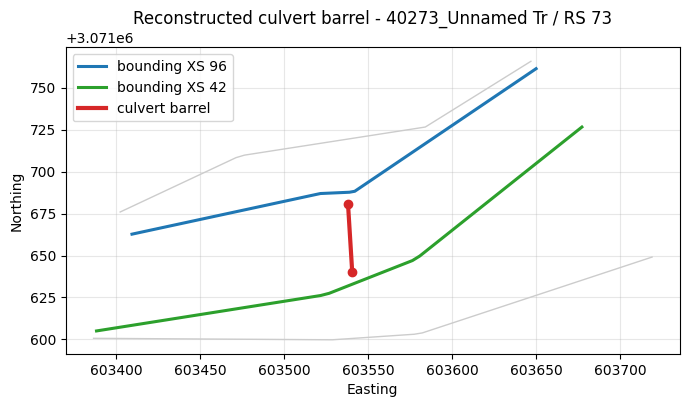

In [5]:
barrels = GeomCulvertGIS.reconstruct_barrels(GEOM_PIPE, RIVER, REACH, RS)
display(barrels[["CulvertName", "Barrel", "planimetric_length",
                 "entered_length", "length_error_pct"]])

adj = GeomCulvert.get_adjacent_cross_sections(GEOM_PIPE, RIVER, REACH, RS)
us_rs, ds_rs = str(adj["upstream"]["RS"]), str(adj["downstream"]["RS"])
xyz = GeomCrossSection.get_xs_coords(GEOM_PIPE, river=RIVER, reach=REACH)

fig, ax = plt.subplots(figsize=(7, 7))
for xs_rs, grp in xyz.groupby("RS"):
    g = grp.sort_values("station")
    ax.plot(g["x"], g["y"], color="0.8", lw=1.0)
for rs_lab, color in [(us_rs, "C0"), (ds_rs, "C2")]:
    g = xyz[xyz["RS"].astype(str) == rs_lab].sort_values("station")
    ax.plot(g["x"], g["y"], color=color, lw=2.2, label=f"bounding XS {rs_lab}")
for _, b in barrels.iterrows():
    ax.plot([b["us_x"], b["ds_x"]], [b["us_y"], b["ds_y"]], color="C3", lw=3,
            label="culvert barrel" if b["Barrel"] == 1 else None)
    ax.scatter([b["us_x"], b["ds_x"]], [b["us_y"], b["ds_y"]], color="C3", zorder=5)
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Reconstructed culvert barrel - {RIVER} / RS {RS}")
ax.set_xlabel("Easting"); ax.set_ylabel("Northing")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Cross-section view with the culvert opening

Plotting the upstream and downstream bounding cross sections with the culvert
opening overlaid makes the **invert-vs-thalweg** check visible: if the opening's
invert sits below the channel low point, the culvert is buried.

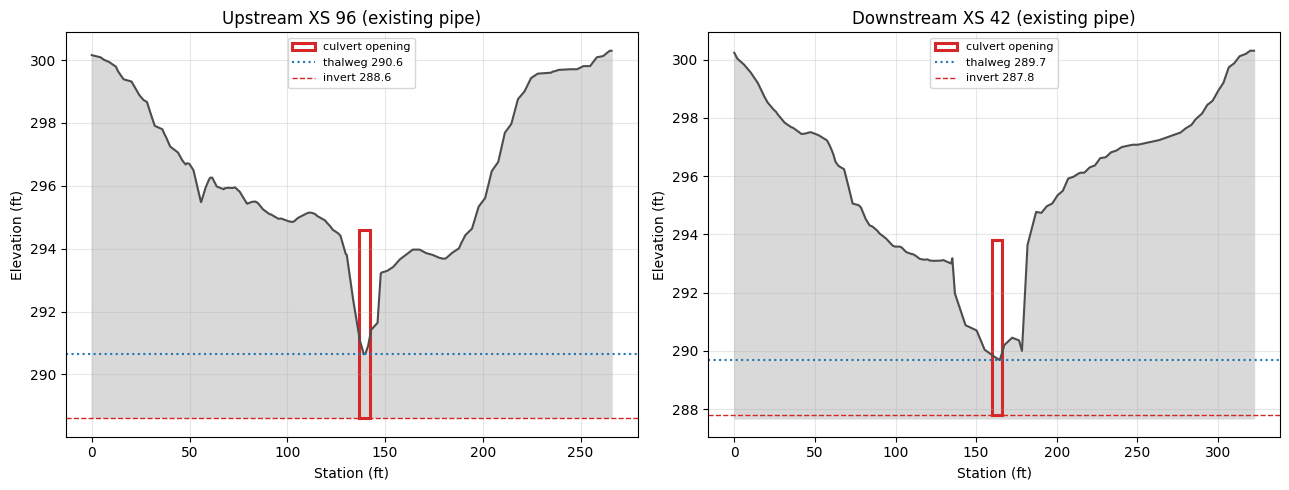

In [6]:
def plot_xs_with_culvert(ax, geom, river, reach, xs_rs, station, invert, rise, span,
                         title, opening_color="C3"):
    se = GeomCrossSection.get_station_elevation(geom, river, reach, xs_rs)
    se = se.sort_values("Station")
    zmin = float(se["Elevation"].min())
    ax.fill_between(se["Station"], se["Elevation"], zmin - 2, color="0.85")
    ax.plot(se["Station"], se["Elevation"], color="0.3", lw=1.5)
    ax.add_patch(Rectangle((station - span / 2, invert), span, rise, fill=False,
                           edgecolor=opening_color, lw=2.2, label="culvert opening"))
    ax.axhline(zmin, color="C0", ls=":", lw=1.5, label=f"thalweg {zmin:.1f}")
    ax.axhline(invert, color=opening_color, ls="--", lw=1.0, label=f"invert {invert:.1f}")
    ax.set_title(title); ax.set_xlabel("Station (ft)"); ax.set_ylabel("Elevation (ft)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)


c = GeomCulvert.get_culverts(GEOM_PIPE, RIVER, REACH, RS).iloc[0]
us_sta, ds_sta = c["BarrelStations"][0]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_xs_with_culvert(axes[0], GEOM_PIPE, RIVER, REACH, us_rs, float(us_sta),
                     float(c["UpstreamInvert"]), float(c["Rise"] if pd.notna(c["Rise"]) else c["Span"]),
                     float(c["Span"]), f"Upstream XS {us_rs} (existing pipe)")
plot_xs_with_culvert(axes[1], GEOM_PIPE, RIVER, REACH, ds_rs, float(ds_sta),
                     float(c["DownstreamInvert"]), float(c["Rise"] if pd.notna(c["Rise"]) else c["Span"]),
                     float(c["Span"]), f"Downstream XS {ds_rs} (existing pipe)")
plt.tight_layout(); plt.show()

## Validate the existing pipe culvert

`validate_placement()` runs the hydraulic-validity checks. For the existing pipe
the inverts are set well below the channel thalweg -- the check flags them.

In [7]:
report_pipe = GeomCulvertGIS.validate_placement(GEOM_PIPE, RIVER, REACH, RS)
display(report_pipe)

,CulvertName,check,status,value,reference,detail
0,Culvert #1,length,REVIEW,1.36,<= 1.0% of entered Length (approx.),reconstructed GIS length vs entered barrel Length
1,Culvert #1,us_invert,FAIL,288.60,>= local bed 290.64 (XS 96),upstream invert vs local bed under opening (gl...
2,Culvert #1,ds_invert,FAIL,287.80,>= local bed 289.68 (XS 42),downstream invert vs local bed under opening (...
3,Culvert #1,entrance_loss,PASS,0.50,HDS-5 ~0.5 (Square edge with headwall),entrance loss Ke vs HDS-5 guidance for inlet
4,Culvert #1,exit_loss,PASS,1.00,~1.0 typical,exit loss coefficient vs typical full-expansio...


## Screen the whole model: pipe vs box invert depth

The check scales to every crossing. Comparing the two designs basin-wide shows a
systematic difference: the SCS **pipe** design sets culvert inverts well below the
streambed (embedded), while the **box** retrofit sits at grade. "Burial" here is
`local_bed - invert` where `local_bed` is the lowest ground **under the opening**
(within span/2 of the barrel station) -- not a far-off cross-section low point
(positive = invert below the local streambed).

In [8]:
def local_bed(geom, river, reach, xs_rs, station, span):
    """Lowest ground within span/2 of the culvert station (the bed under the
    opening, not a far-off XS low point)."""
    se = GeomCrossSection.get_station_elevation(geom, river, reach, xs_rs)
    sta = se["Station"].astype(float)
    near = se[(sta >= station - span / 2) & (sta <= station + span / 2)]
    if len(near):
        return float(near["Elevation"].min())
    return float(np.interp(station, se["Station"].astype(float), se["Elevation"]))

def burial_table(geom):
    rows = []
    for _, s in GeomCulvert.get_all(geom).iterrows():
        river, reach, rs = s["River"], s["Reach"], str(s["RS"])
        cc = GeomCulvert.get_culverts(geom, river, reach, rs).iloc[0]
        adj = GeomCulvert.get_adjacent_cross_sections(geom, river, reach, rs)
        us_sta, ds_sta = cc["BarrelStations"][0]
        span = float(cc["Span"])
        us_bed = local_bed(geom, river, reach, str(adj["upstream"]["RS"]), float(us_sta), span)
        ds_bed = local_bed(geom, river, reach, str(adj["downstream"]["RS"]), float(ds_sta), span)
        rows.append({"River": river, "RS": rs,
                     "us_burial": round(us_bed - float(cc["UpstreamInvert"]), 2),
                     "ds_burial": round(ds_bed - float(cc["DownstreamInvert"]), 2)})
    return pd.DataFrame(rows)

pipe_b = burial_table(GEOM_PIPE)
box_b = burial_table(GEOM_BOX)
tol = GeomCulvertGIS.INVERT_TOLERANCE
n_pipe = int(((pipe_b["us_burial"] > tol) | (pipe_b["ds_burial"] > tol)).sum())
n_box = int(((box_b["us_burial"] > tol) | (box_b["ds_burial"] > tol)).sum())
print(f"crossings: {len(pipe_b)}")
print(f"  PIPE: {n_pipe} with invert below thalweg | median US burial "
      f"{pipe_b['us_burial'].median():.2f} ft, max {pipe_b['us_burial'].max():.2f} ft")
print(f"  BOX : {n_box} with invert below thalweg | median US burial "
      f"{box_b['us_burial'].median():.2f} ft, max {box_b['us_burial'].max():.2f} ft")

contrast = pipe_b[["River", "RS", "us_burial"]].rename(columns={"us_burial": "pipe_US_burial"})
contrast = contrast.merge(
    box_b[["River", "RS", "us_burial"]].rename(columns={"us_burial": "box_US_burial"}),
    on=["River", "RS"])
display(contrast.sort_values("pipe_US_burial", ascending=False).head(12))

crossings: 16
  PIPE: 16 with invert below thalweg | median US burial 2.16 ft, max 5.10 ft
  BOX : 7 with invert below thalweg | median US burial 0.04 ft, max 2.26 ft


,River,RS,pipe_US_burial,box_US_burial
7,55504_Unnamed Tr,102,5.10,-0.00
5,55501_Witch Broo,111,4.94,1.54
13,58453,99,4.86,2.26
8,55571_Unnamed Tr,105,4.65,-0.15
6,55502_Squannacoo,77,2.86,-0.04
1,40382_Unnamed Tr,96,2.25,0.25
10,58069_Unnamed Tr,69,2.20,0.20
12,58444_Unnamed Tr,55,2.17,0.17
15,73671_Unnamed Tr,81,2.14,0.14
0,40273_Unnamed Tr,73,2.04,0.04


## Real-world improvement: pipe -> box retrofit

The box-retrofit geometry sets the culvert at grade. Validating it, the invert
checks now pass. (The box is the study's design value -- a tall opening with a
much larger flow area than the 6 ft pipe, which is what lowers the headwater; its
`span`/`rise` are read straight from the geometry per the HEC-RAS field order.)

In [9]:
cb = GeomCulvert.get_culverts(GEOM_BOX, RIVER, REACH, RS).iloc[0]
print(f"Existing pipe : {c['ShapeName']} span={c['Span']} rise={c['Rise']} "
      f"US inv={c['UpstreamInvert']} DS inv={c['DownstreamInvert']}")
print(f"Box retrofit  : {cb['ShapeName']} span={cb['Span']} rise={cb['Rise']} "
      f"US inv={cb['UpstreamInvert']} DS inv={cb['DownstreamInvert']}")
report_box = GeomCulvertGIS.validate_placement(GEOM_BOX, RIVER, REACH, RS)
display(report_box)

Existing pipe : Circular span=6.0 rise=6.0 US inv=288.6 DS inv=287.8
Box retrofit  : Box span=4.0 rise=20.0 US inv=290.6 DS inv=289.8


,CulvertName,check,status,value,reference,detail
0,Culvert #1,length,REVIEW,1.36,<= 1.0% of entered Length (approx.),reconstructed GIS length vs entered barrel Length
1,Culvert #1,us_invert,PASS,290.60,>= local bed 290.64 (XS 96),upstream invert vs local bed under opening (gl...
2,Culvert #1,ds_invert,PASS,289.80,>= local bed 289.68 (XS 42),downstream invert vs local bed under opening (...
3,Culvert #1,entrance_loss,WARN,0.50,HDS-5 ~0.2 (Side tapered; More favorable edges),entrance loss Ke vs HDS-5 guidance for inlet
4,Culvert #1,exit_loss,PASS,1.00,~1.0 typical,exit loss coefficient vs typical full-expansio...


## Hydraulic comparison: compute pre (pipe) and post (box)

Both are steady runs (~5 s each). We compare the water-surface profile on the
crossing's reach -- the headwater upstream of the culvert.

In [10]:
def run_and_wse(plan):
    ok = RasCmdr.compute_plan(plan, ras_object=ras, force_geompre=True,
                              force_rerun=True, num_cores=1, verify=True)
    if not ok:
        raise RuntimeError(f"compute failed for plan {plan}")
    return HdfResultsPlan.get_steady_wse(plan, ras_object=ras)

t0 = time.perf_counter()
wse_pipe = run_and_wse(PLAN_PIPE)
wse_box = run_and_wse(PLAN_BOX)
print(f"both plans computed in {time.perf_counter() - t0:.1f} s")

import re
def aep_pct(name):
    m = re.search(r"([\d.]+)\s*-?\s*percent", str(name).lower())
    return float(m.group(1)) if m else float("inf")
# largest event = smallest annual-exceedance-probability percent
prof = min(wse_pipe["Profile"].unique(), key=aep_pct)
def reach_wse(wse):
    w = wse[(wse["River"] == RIVER) & (wse["Profile"] == prof)].copy()
    w["sta"] = w["Station"].astype(str).str.replace("*", "", regex=False).astype(float)
    return w.sort_values("sta")

w_pipe, w_box = reach_wse(wse_pipe), reach_wse(wse_box)
headwater_pipe = w_pipe["WSE"].max()
headwater_box = w_box["WSE"].max()
print(f"profile: {prof}")
print(f"max headwater  pipe={headwater_pipe:.2f} ft  box={headwater_box:.2f} ft  "
      f"reduction={headwater_pipe - headwater_box:.2f} ft")

both plans computed in 7.1 s
profile: 0.2-percent AEP
max headwater  pipe=297.13 ft  box=295.62 ft  reduction=1.51 ft


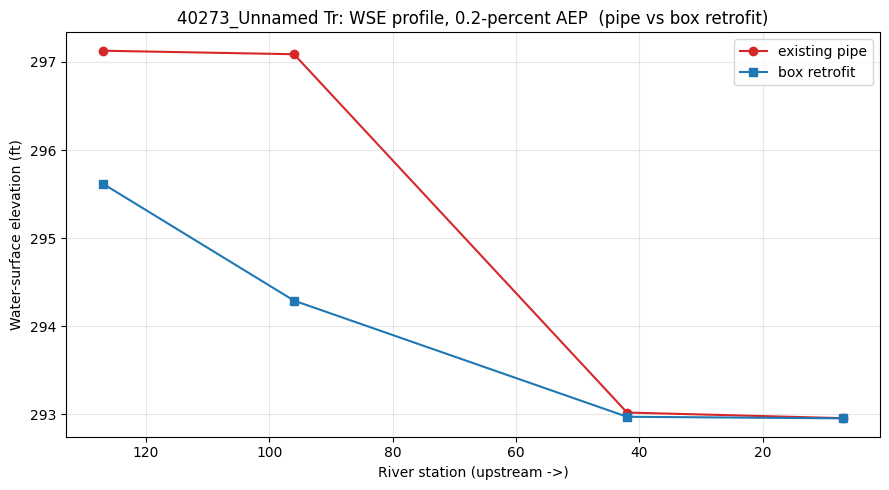

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(w_pipe["sta"], w_pipe["WSE"], marker="o", color="C3", label="existing pipe")
ax.plot(w_box["sta"], w_box["WSE"], marker="s", color="C0", label="box retrofit")
ax.invert_xaxis()  # upstream to the left
ax.set_xlabel("River station (upstream ->)")
ax.set_ylabel("Water-surface elevation (ft)")
ax.set_title(f"{RIVER}: WSE profile, {prof}  (pipe vs box retrofit)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Pre/post cross-section view

The upstream cross section with the existing pipe opening (pre) and the box
opening (post). The box sits at grade and passes more flow at a lower headwater.

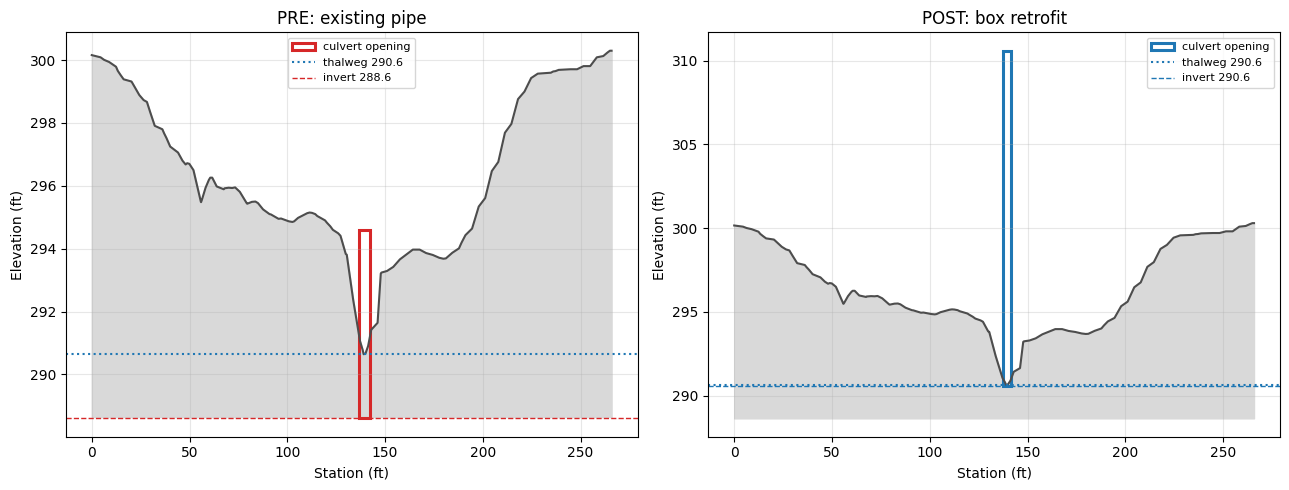

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
us_sta_p, _ = c["BarrelStations"][0]
us_sta_b, _ = cb["BarrelStations"][0]
plot_xs_with_culvert(axes[0], GEOM_PIPE, RIVER, REACH, us_rs, float(us_sta_p),
                     float(c["UpstreamInvert"]),
                     float(c["Rise"] if pd.notna(c["Rise"]) else c["Span"]),
                     float(c["Span"]), "PRE: existing pipe", opening_color="C3")
plot_xs_with_culvert(axes[1], GEOM_BOX, RIVER, REACH, us_rs, float(us_sta_b),
                     float(cb["UpstreamInvert"]),
                     float(cb["Rise"] if pd.notna(cb["Rise"]) else cb["Span"]),
                     float(cb["Span"]), "POST: box retrofit", opening_color="C0")
plt.tight_layout(); plt.show()

## Summary

In [13]:
def status_of(rep, check):
    r = rep[rep["check"] == check]
    return r.iloc[0]["status"] if not r.empty else "N/A"

summary = pd.DataFrame([
    {"Design": "Existing pipe", "Shape": c["ShapeName"], "Span": c["Span"],
     "US invert": c["UpstreamInvert"], "max headwater (ft)": round(headwater_pipe, 2),
     "US invert check": status_of(report_pipe, "us_invert"),
     "Ke check": status_of(report_pipe, "entrance_loss")},
    {"Design": "Box retrofit", "Shape": cb["ShapeName"], "Span": cb["Span"],
     "US invert": cb["UpstreamInvert"], "max headwater (ft)": round(headwater_box, 2),
     "US invert check": status_of(report_box, "us_invert"),
     "Ke check": status_of(report_box, "entrance_loss")},
])
display(summary)
print(f"Box retrofit lowers peak headwater by {headwater_pipe - headwater_box:.2f} ft "
      f"and places the invert at grade (invert check passes).")
print("Culvert GIS reconstruction + hydraulic-validity workflow complete.")

,Design,Shape,Span,US invert,max headwater (ft),US invert check,Ke check
0,Existing pipe,Circular,6.0,288.6,297.13,FAIL,PASS
1,Box retrofit,Box,4.0,290.6,295.62,PASS,WARN


Box retrofit lowers peak headwater by 1.51 ft and places the invert at grade (invert check passes).
Culvert GIS reconstruction + hydraulic-validity workflow complete.
